In [69]:
import os
import random
from PIL import Image
import glob
from pathlib import Path

In [70]:
def walk_though_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")

dir_path = "data/clf-data"
walk_though_dir(dir_path)

There are 2 directories and 0 images in 'data/clf-data'
There are 0 directories and 3045 images in 'data/clf-data\empty'
There are 0 directories and 3045 images in 'data/clf-data\not_empty'


In [71]:
random.seed(42)
img_path_list = glob.glob(f"{dir_path}/*/*.jpg")
random_img_path = random.choice(img_path_list)
img_class = Path(random_img_path).parent.stem

img = Image.open(random_img_path)
print(f"Random image path: {img}")
print(f"Image class: {img_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img



Random image path: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=68x28 at 0x25F110C30E0>
Image class: not_empty
Image height: 28
Image width: 68


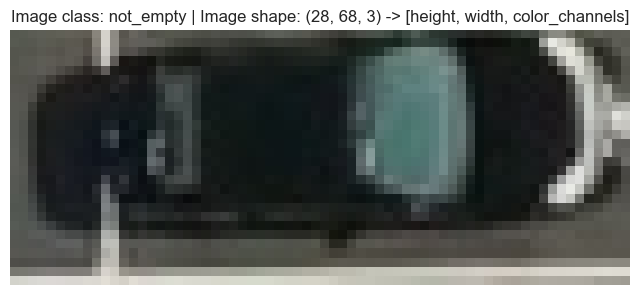

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

img_as_array = np.asarray(img)

plt.figure(figsize=(8, 6))
plt.imshow(img_as_array)
plt.title(f"Image class: {img_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

In [73]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

IMAGE_HEIGHT = 128
IMAGE_WEIDHT = 128
IMAGE_SHAPE = (IMAGE_HEIGHT, IMAGE_WEIDHT)

train_transform = transforms.Compose([
    transforms.Resize(size=IMAGE_SHAPE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=IMAGE_SHAPE),
    transforms.ToTensor()
])

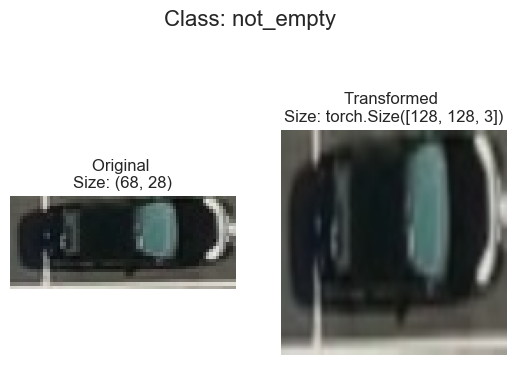

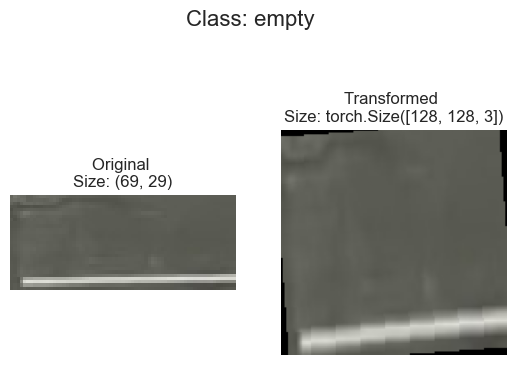

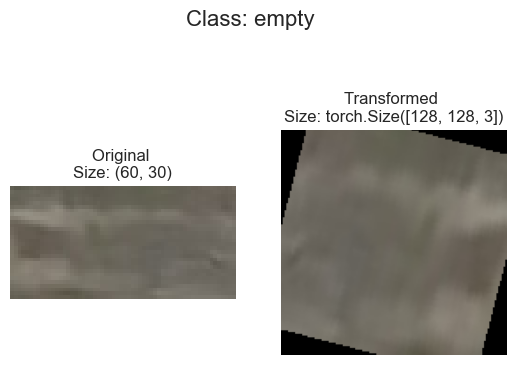

In [74]:
def plot_transformed_images(img_paths, transform, n=3, seed=42):
    random.seed(seed)

    random_img_path = random.sample(img_paths, k=n)

    for img_path in random_img_path:
        with Image.open(img_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            transformed_img = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_img) 
            ax[1].set_title(f"Transformed \nSize: {transformed_img.shape}")
            ax[1].axis("off")
            fig.suptitle(f"Class: {Path(img_path).parent.stem}", fontsize=16)
            
plot_transformed_images(img_path_list, transform=train_transform, n=3);     

In [75]:
from torch.utils.data import Subset

# 1) Build a base dataset to get stable indices and class metadata
base_dataset = datasets.ImageFolder(root=dir_path)

# 2) Split train/test directly in code (no need train/ and test/ folders)
train_ratio = 0.8
train_size = int(train_ratio * len(base_dataset))

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(base_dataset), generator=generator).tolist()
train_indices = indices[:train_size]
test_indices = indices[train_size:]

train_full = datasets.ImageFolder(root=dir_path, transform=train_transform)
test_full = datasets.ImageFolder(root=dir_path, transform=test_transform)

train_dataset = Subset(train_full, train_indices)
test_dataset = Subset(test_full, test_indices)

BATCH_SIZE = 32
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total images: {len(base_dataset)}")
print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"Class names: {base_dataset.classes}")

Total images: 6090
Train size: 4872
Test size: 1218
Class names: ['empty', 'not_empty']


In [76]:
img, label = next(iter(train_dataloader))

# Note that batch size will now be 1.  
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 128, 128]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


In [77]:
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device

class ImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layer_1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2)
        )
        self.conv_layer_2 = nn.Sequential(
            nn.Conv2d(64, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(2)
        )
        self.conv_layer_3 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=512 * 16 * 16, out_features=2)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_layer_1(x)
        x = self.conv_layer_2(x)
        x = self.conv_layer_3(x)
        x = self.classifier(x)
        return x

model = ImageClassifier().to(device)

In [78]:
img_batch, label_batch = next(iter(train_dataloader))

img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

model.eval()
with torch.inference_mode():
    pred = model(img_single.to(device))
    
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 128, 128])

Output logits:
tensor([[ 0.0257, -0.0006]])

Output prediction probabilities:
tensor([[0.5066, 0.4934]])

Output prediction label:
tensor([0])

Actual label:
1


In [79]:
from torchinfo import summary
summary(model, input_size=[1, 3, IMAGE_WEIDHT ,IMAGE_HEIGHT]) 

Layer (type:depth-idx)                   Output Shape              Param #
ImageClassifier                          [1, 2]                    --
├─Sequential: 1-1                        [1, 64, 64, 64]           --
│    └─Conv2d: 2-1                       [1, 64, 128, 128]         1,792
│    └─ReLU: 2-2                         [1, 64, 128, 128]         --
│    └─BatchNorm2d: 2-3                  [1, 64, 128, 128]         128
│    └─MaxPool2d: 2-4                    [1, 64, 64, 64]           --
├─Sequential: 1-2                        [1, 512, 32, 32]          --
│    └─Conv2d: 2-5                       [1, 512, 64, 64]          295,424
│    └─ReLU: 2-6                         [1, 512, 64, 64]          --
│    └─BatchNorm2d: 2-7                  [1, 512, 64, 64]          1,024
│    └─MaxPool2d: 2-8                    [1, 512, 32, 32]          --
├─Sequential: 1-3                        [1, 512, 16, 16]          --
│    └─Conv2d: 2-9                       [1, 512, 32, 32]          2,359,

In [80]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

run_name = f"cnn_parking_e{NUM_EPOCHS}_bs{BATCH_SIZE}_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
writer = SummaryWriter(log_dir=f"runs/{run_name}")

os.makedirs("model", exist_ok=True)
# best_model_path = os.path.join("model", "best_cnn_model.pth")

sample_imgs, _ = next(iter(train_dataloader))
writer.add_images("train_samples_augmented", sample_imgs[:8], 0)

best_test_loss = float("inf")
final_test_acc = 0.0

for epoch in range(NUM_EPOCHS):
    # ---- Train ----
    model.train()
    train_loss_total = 0.0
    train_correct = 0
    train_total = 0

    for X, y in train_dataloader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss_total += loss.item() * X.size(0)
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == y).sum().item()
        train_total += y.size(0)

    train_loss = train_loss_total / train_total
    train_acc = train_correct / train_total

    # ---- Test ----
    model.eval()
    test_loss_total = 0.0
    test_correct = 0
    test_total = 0

    all_test_labels = []
    all_test_probs = []
    conf_mat = torch.zeros(2, 2, dtype=torch.int64)

    with torch.inference_mode():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)

            test_loss_total += loss.item() * X.size(0)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            test_correct += (preds == y).sum().item()
            test_total += y.size(0)

            for t, p in zip(y.cpu(), preds.cpu()):
                conf_mat[t.long(), p.long()] += 1

            all_test_labels.append(y.detach().cpu())
            all_test_probs.append(probs[:, 1].detach().cpu())

    test_loss = test_loss_total / test_total
    test_acc = test_correct / test_total
    final_test_acc = test_acc

    tn = conf_mat[0, 0].item()
    fp = conf_mat[0, 1].item()
    fn = conf_mat[1, 0].item()
    tp = conf_mat[1, 1].item()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    scheduler.step(test_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Acc/train", train_acc, epoch)
    writer.add_scalar("Acc/test", test_acc, epoch)
    writer.add_scalar("LR", current_lr, epoch)
    writer.add_scalar("Metrics/test_precision", precision, epoch)
    writer.add_scalar("Metrics/test_recall", recall, epoch)
    writer.add_scalar("Metrics/test_f1", f1, epoch)

    if epoch in [0, 4, 9, 19, 29]:
        writer.add_text(
            "ConfusionMatrix/test",
            f"epoch={epoch+1} | TN={tn}, FP={fp}, FN={fn}, TP={tp}",
            epoch
        )

    if all_test_labels:
        y_true = torch.cat(all_test_labels).numpy()
        y_score = torch.cat(all_test_probs).numpy()
        writer.add_pr_curve("PR/test_not_empty", y_true, y_score, global_step=epoch)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"train_loss={train_loss:.4f} test_loss={test_loss:.4f} "
        f"train_acc={train_acc:.4f} test_acc={test_acc:.4f} lr={current_lr:.6f}"
    )

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), best_model_path)

writer.add_hparams(
    {
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "rotation_degree": 45,
        "optimizer": "Adam"
    },
    {
        "hparam/best_test_loss": best_test_loss,
        "hparam/final_test_acc": final_test_acc
    }
)

writer.close()
print(f"Best model saved to: {best_model_path}")
print("Open TensorBoard with: tensorboard --logdir runs")

Epoch [1/30] train_loss=0.1562 test_loss=0.0012 train_acc=0.9750 test_acc=0.9992 lr=0.000100


KeyboardInterrupt: 